# About the dataset
# Precision agriculture is in trend nowadays. It helps farmers make informed decisions about farming strategy. 
#This dataset enables users to build a predictive model to recommend the most suitable crops to grow in a particular farm based on various soil and climate parameters.

#This dataset was built by augmenting datasets of rainfall, climate, and fertilizer data available for India. 
#It contains 2,200 records across 22 crop types with perfectly balanced classes (100 samples each).

In [1]:
'''Data fields
N - ratio of Nitrogen content in soil
P - ratio of Phosphorous content in soil
K - ratio of Potassium content in soil
temperature - temperature in degree Celsius
humidity - relative humidity in %
ph - ph value of the soil
rainfall - rainfall in mm'''

'Data fields\nN - ratio of Nitrogen content in soil\nP - ratio of Phosphorous content in soil\nK - ratio of Potassium content in soil\ntemperature - temperature in degree Celsius\nhumidity - relative humidity in %\nph - ph value of the soil\nrainfall - rainfall in mm'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib

# Machine Learning Modules
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score)

warnings.filterwarnings('ignore')

# ─── Global Visual Theme ────────────────────────────────────────────────────────
BG      = "#f8fdf9"
GREEN   = "#1b5e20"
PALETTE = ["#1b5e20", "#2e7d32", "#388e3c", "#43a047",
           "#66bb6a", "#81c784", "#a5d6a7", "#c8e6c9"]

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.facecolor"  : BG,
    "axes.facecolor"    : BG,
    "axes.edgecolor"    : "#c8e6c9",
    "axes.linewidth"    : 1.2,
    "grid.color"        : "#e8f5e9",
    "grid.linewidth"    : 0.8,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.color"       : "#37474f",
    "ytick.color"       : "#37474f",
    "axes.labelcolor"   : "#37474f",
    "axes.labelsize"    : 12,
    "axes.titlesize"    : 15,
    "axes.titleweight"  : "bold",
    "axes.titlecolor"   : GREEN,
    "font.size"         : 11,
    "legend.frameon"    : True,
    "legend.framealpha" : 0.92,
    "figure.dpi"        : 110,
})

print(" Libraries imported & global theme configured.")

 Libraries imported & global theme configured.


In [3]:
# Load the dataset
df = pd.read_csv("../data/Crop_recommendation.csv")

# If running locally without Kaggle path structure, fallback to local path:
# df = pd.read_csv('Crop_recommendation.csv')

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# Check for missing values and data types
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

# Describe numeric features
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicated Rows: 0


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


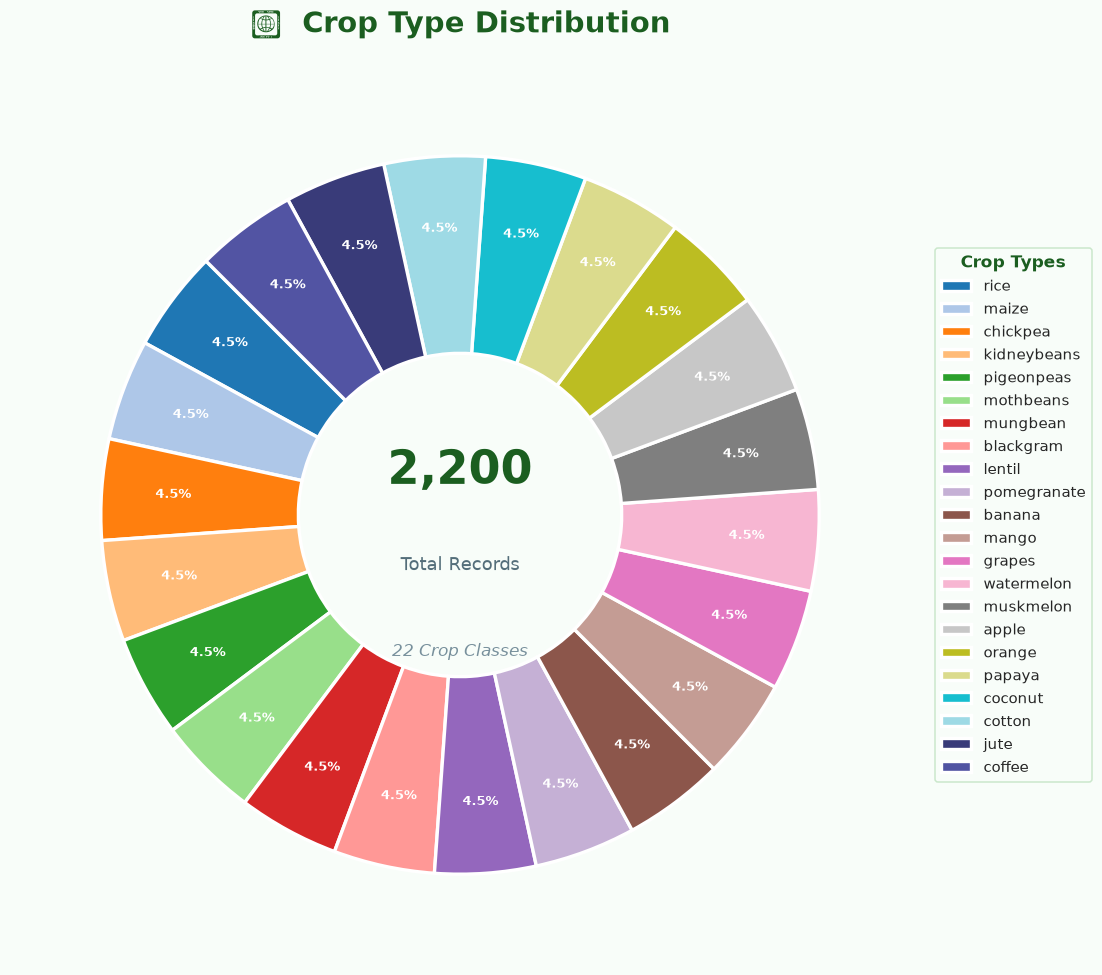

In [9]:
# Exploratory data analysis
# ─── 3.1  Target Class Distribution (Donut Chart) ───────────────────────────
counts  = df['label'].value_counts().sort_values(ascending=False)
n_crops = len(counts)

# 22-colour rich palette
colors = (sns.color_palette("tab20", 20) + sns.color_palette("tab20b", 4))[:n_crops]

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    counts,
    labels=None,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 4.0 else '',
    startangle=135,
    pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.2),
    textprops=dict(size=9),
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(8.5)

# ── Center annotation ──
ax.text(0,  0.12, "2,200",      ha='center', va='center', fontsize=30,
        fontweight='bold', color=GREEN)
ax.text(0, -0.14, "Total Records", ha='center', va='center', fontsize=12,
        color='#546e7a')
ax.text(0, -0.38, f"{n_crops} Crop Classes", ha='center', va='center',
        fontsize=11, color='#78909c', style='italic')

# ── Legend ──
legend = ax.legend(
    wedges, counts.index,
    title="Crop Types", title_fontsize=11,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    fontsize=10, frameon=True, framealpha=0.95, edgecolor='#c8e6c9',
    ncol=1,
)
legend.get_title().set_color(GREEN)
legend.get_title().set_fontweight('bold')

ax.set_title("🌾  Crop Type Distribution", fontsize=19, fontweight='bold',
             pad=22, color=GREEN)
plt.tight_layout()

plt.savefig(
    "../results/crop_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

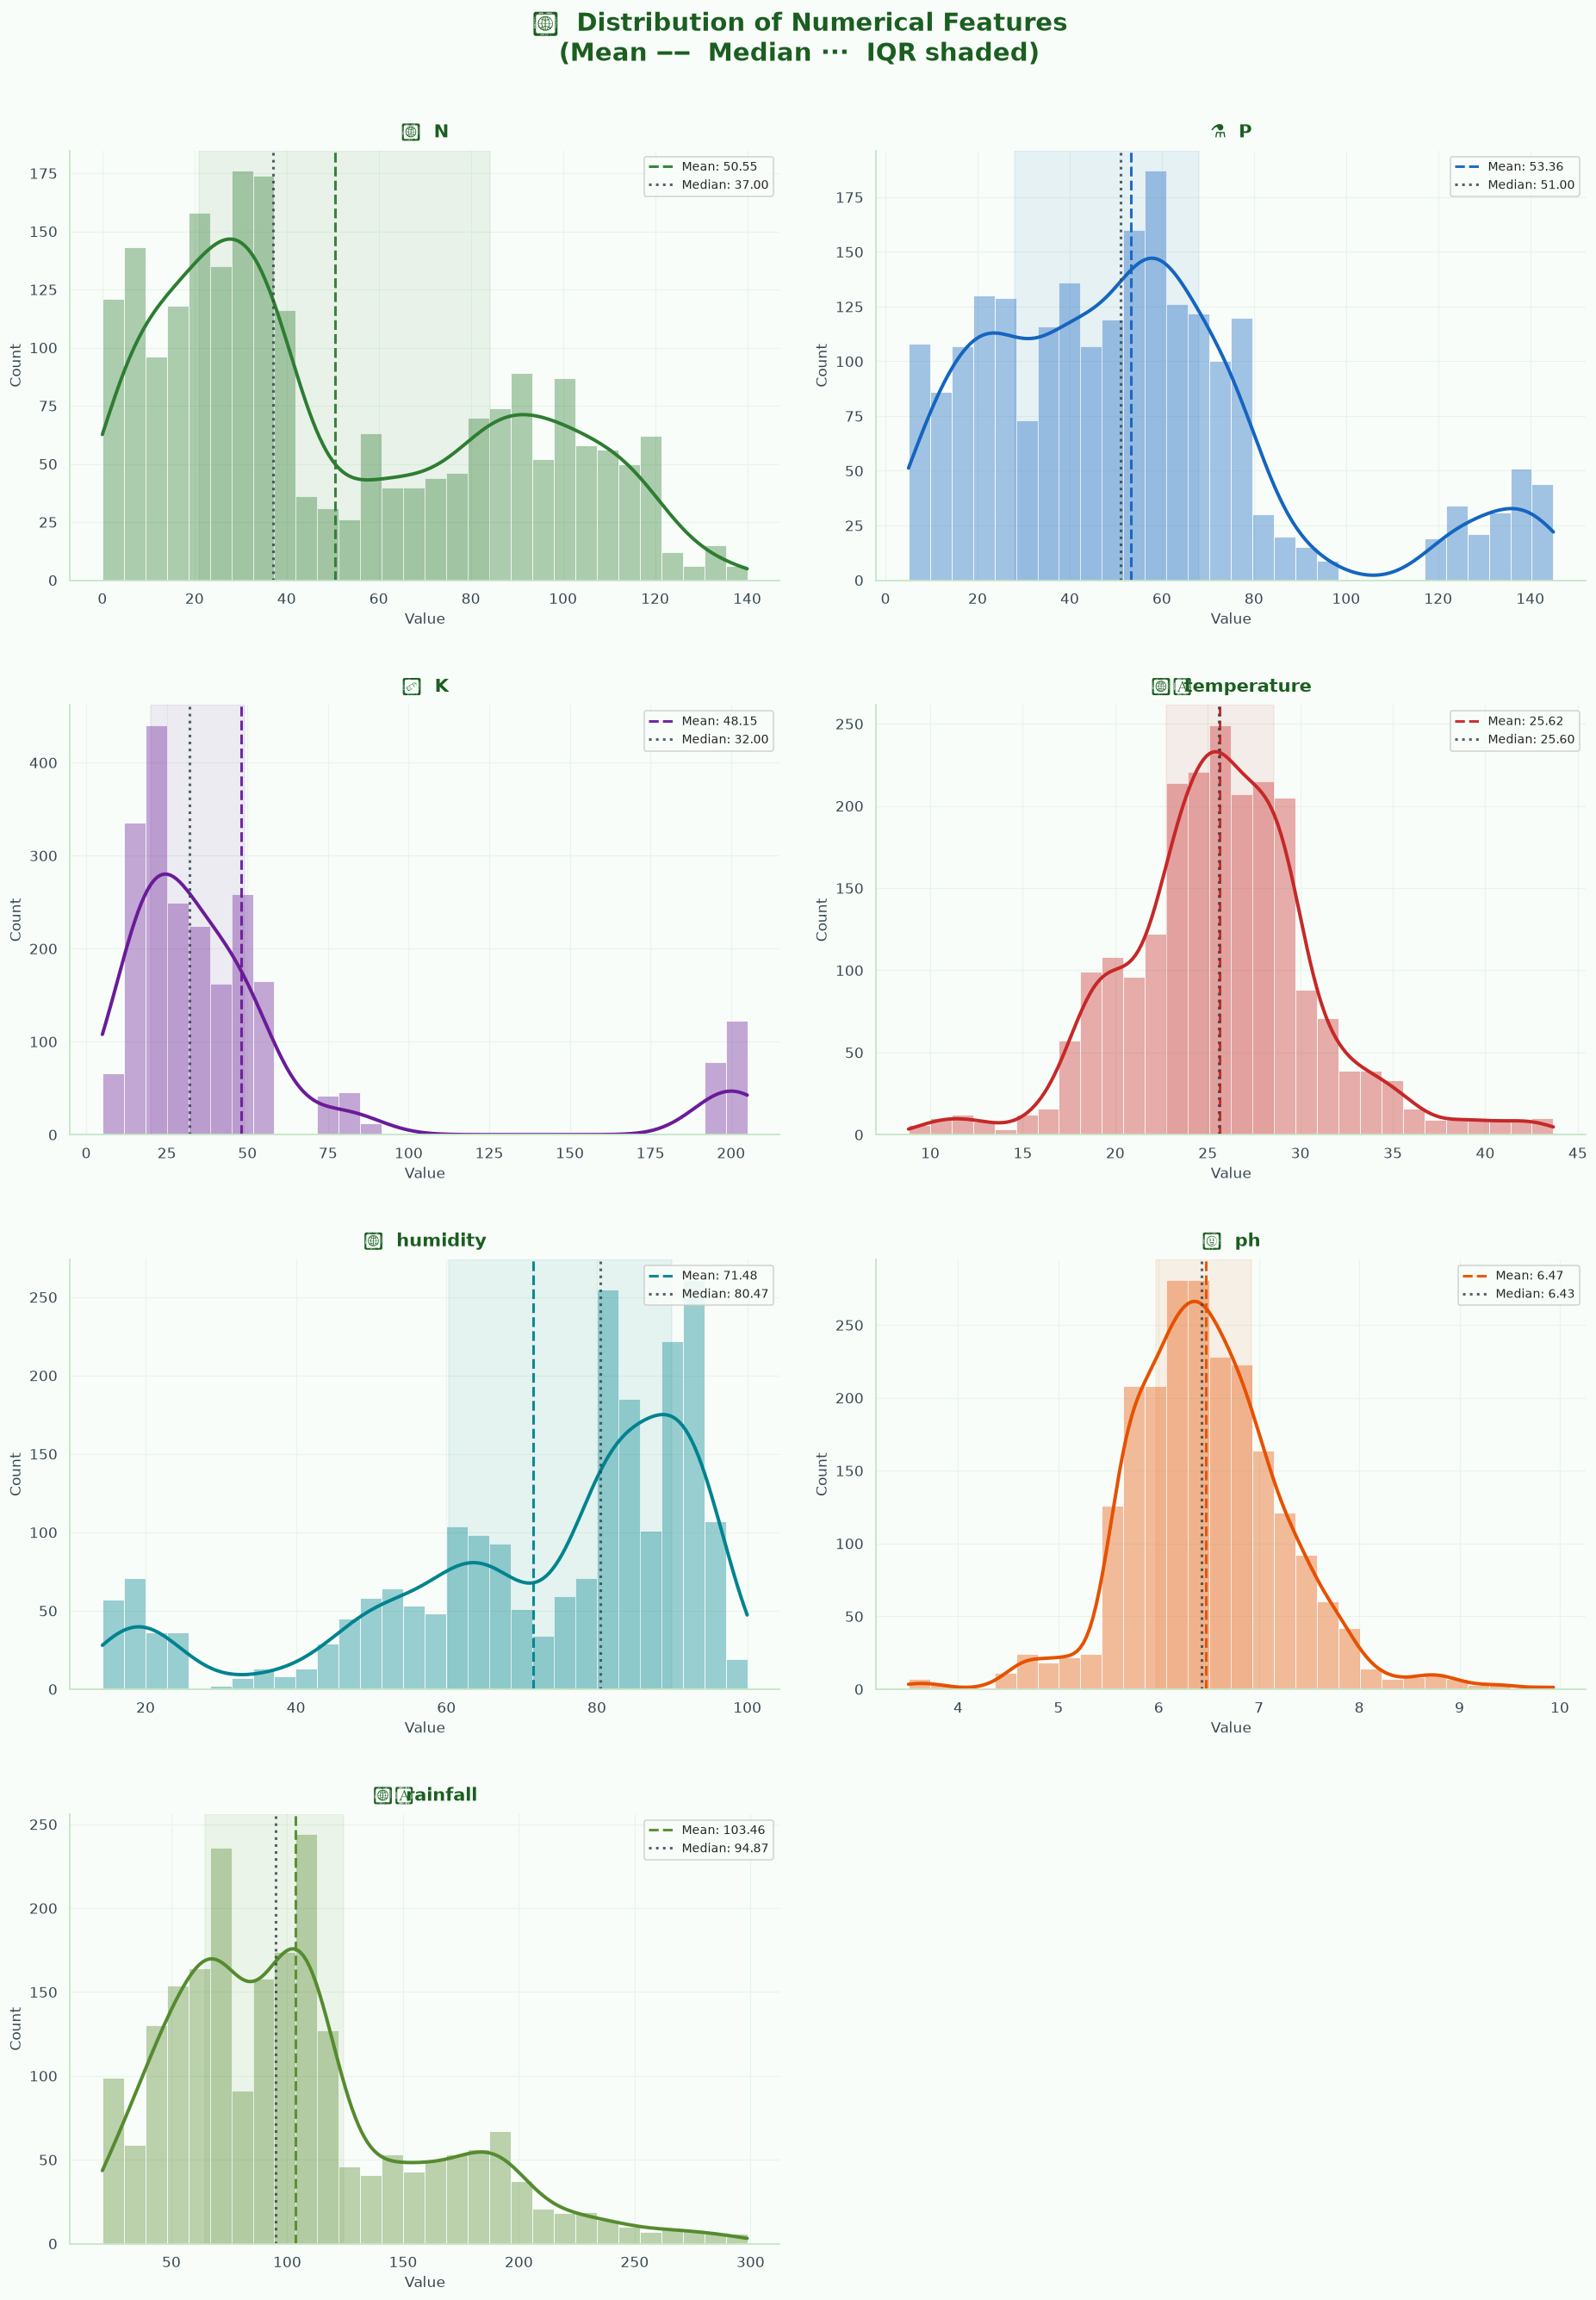

In [10]:
# ─── 3.2  Distribution of Numerical Features ────────────────────────────────
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
feat_colors  = ['#2e7d32', '#1565c0', '#6a1b9a', '#c62828', '#00838f', '#e65100', '#558b2f']
feat_icons   = ['🌿', '⚗️', '🪨', '🌡️', '💧', '🧪', '🌧️']

fig, axes = plt.subplots(4, 2, figsize=(17, 24), facecolor=BG)
axes = axes.flatten()

for i, (col, color, icon) in enumerate(zip(num_features, feat_colors, feat_icons)):
    ax = axes[i]
    ax.set_facecolor(BG)
    data = df[col]

    # Filled histogram + KDE
    sns.histplot(data, kde=True, ax=ax, color=color, bins=30,
                 alpha=0.38, edgecolor='white', linewidth=0.5)
    # Thicken the KDE line
    for line in ax.get_lines():
        line.set_linewidth(2.6)
        line.set_color(color)

    # Mean & Median reference lines
    mean_val   = data.mean()
    median_val = data.median()
    ymax = ax.get_ylim()[1]
    ax.axvline(mean_val,   color=color,     lw=2.0, ls='--', alpha=0.95,
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#37474f', lw=2.0, ls=':',  alpha=0.85,
               label=f'Median: {median_val:.2f}')

    # Shaded IQR band
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    ax.axvspan(q1, q3, alpha=0.08, color=color)

    ax.set_title(f'{icon}  {col}', fontsize=14, fontweight='bold',
                 color=GREEN, pad=10)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9, loc='upper right', framealpha=0.88)

# Hide the unused 8th subplot
axes[-1].set_visible(False)

fig.suptitle("📊  Distribution of Numerical Features\n(Mean ‒‒  Median ···  IQR shaded)",
             fontsize=19, fontweight='bold', color=GREEN, y=1.01)
plt.tight_layout(h_pad=3.5, w_pad=2.5)

plt.savefig(
    "../results/distribution_of_numerical_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

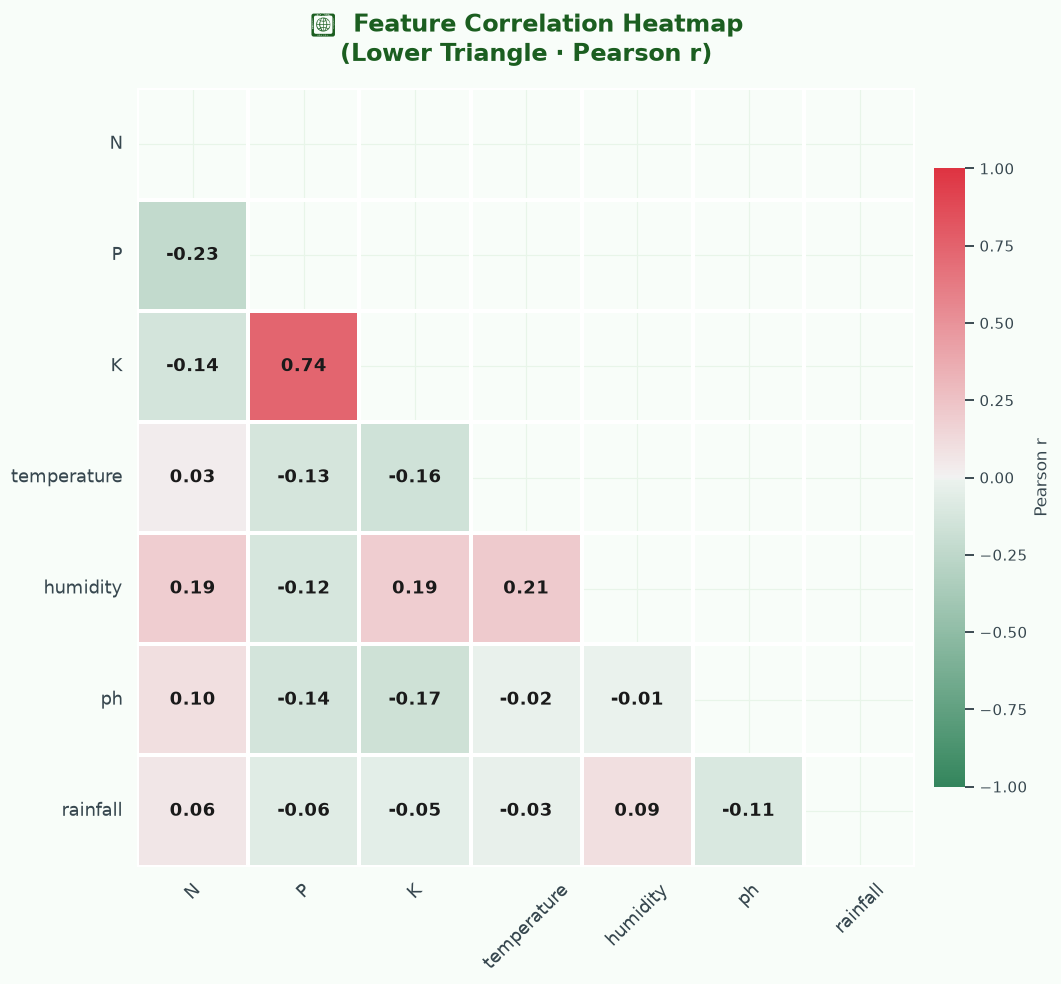

In [11]:
# ─── 3.3  Feature Correlation Heatmap ───────────────────────────────────────
corr = df[num_features].corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

# Custom green ↔ white ↔ red diverging palette
cmap = sns.diverging_palette(145, 10, s=80, l=50, as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
ax.set_facecolor(BG)

hm = sns.heatmap(
    corr, mask=mask, cmap=cmap,
    annot=True, fmt='.2f',
    annot_kws={'size': 12, 'weight': 'bold', 'color': '#1a1a1a'},
    linewidths=2.5, linecolor='white',
    vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r', 'pad': 0.02},
)
hm.collections[0].colorbar.ax.tick_params(labelsize=10)
hm.collections[0].colorbar.set_label('Pearson r', fontsize=11, color='#37474f')

ax.set_title("🔥  Feature Correlation Heatmap\n(Lower Triangle · Pearson r)",
             fontsize=16, fontweight='bold', color=GREEN, pad=18)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', rotation=0,  labelsize=12)
plt.tight_layout()

plt.savefig(
    "../results/feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

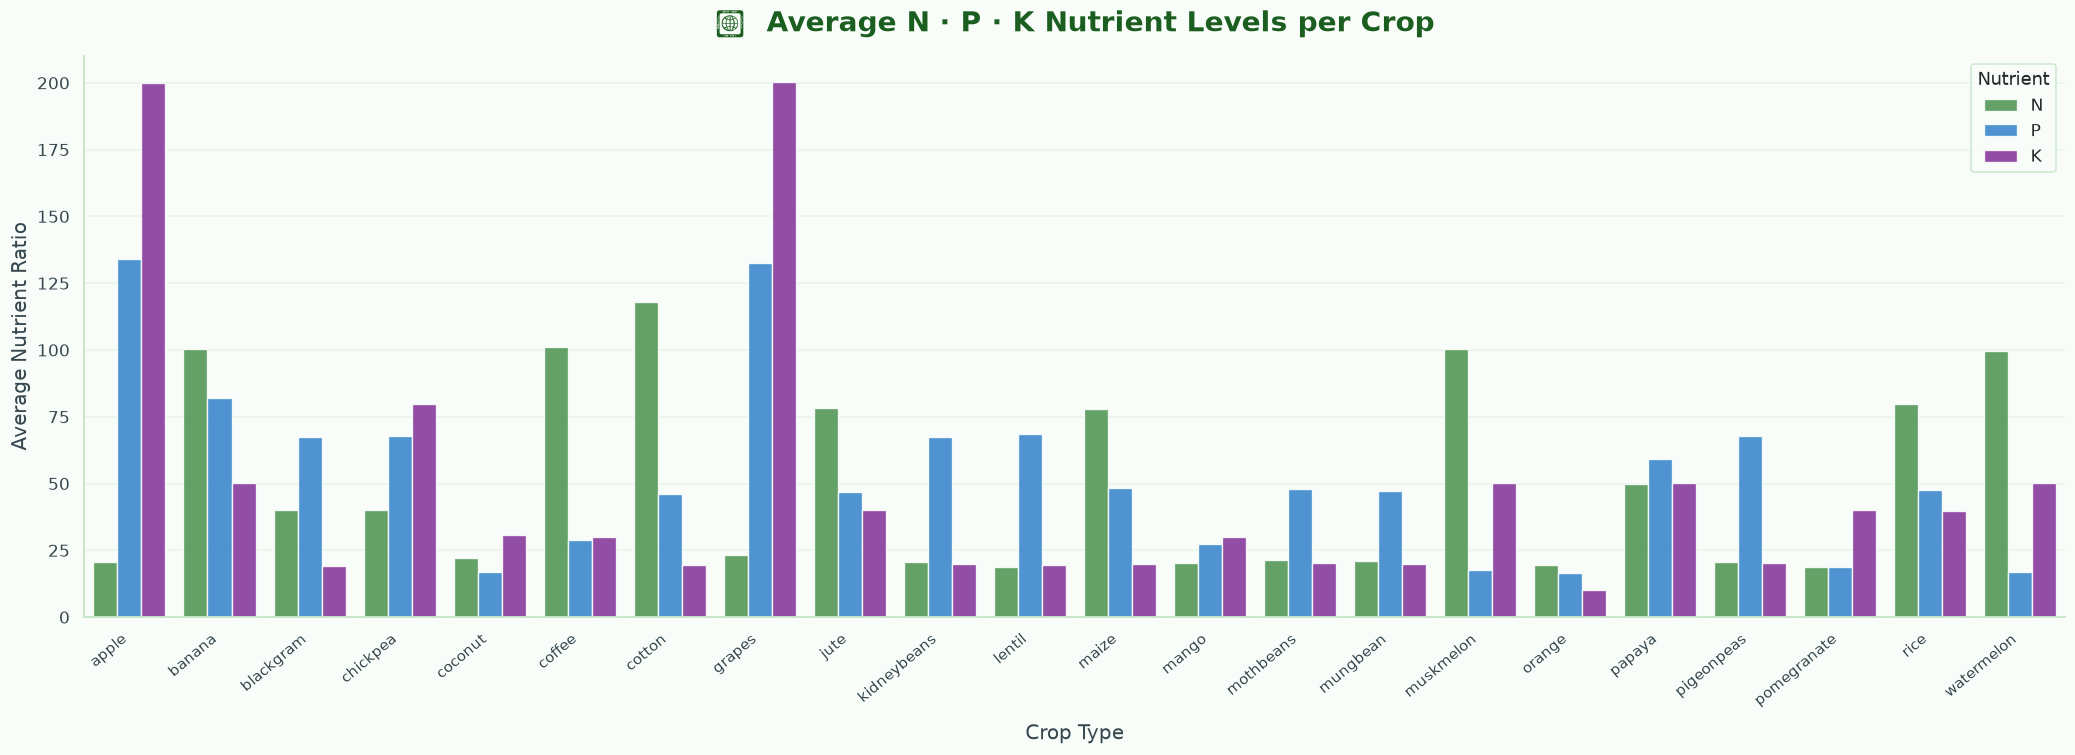

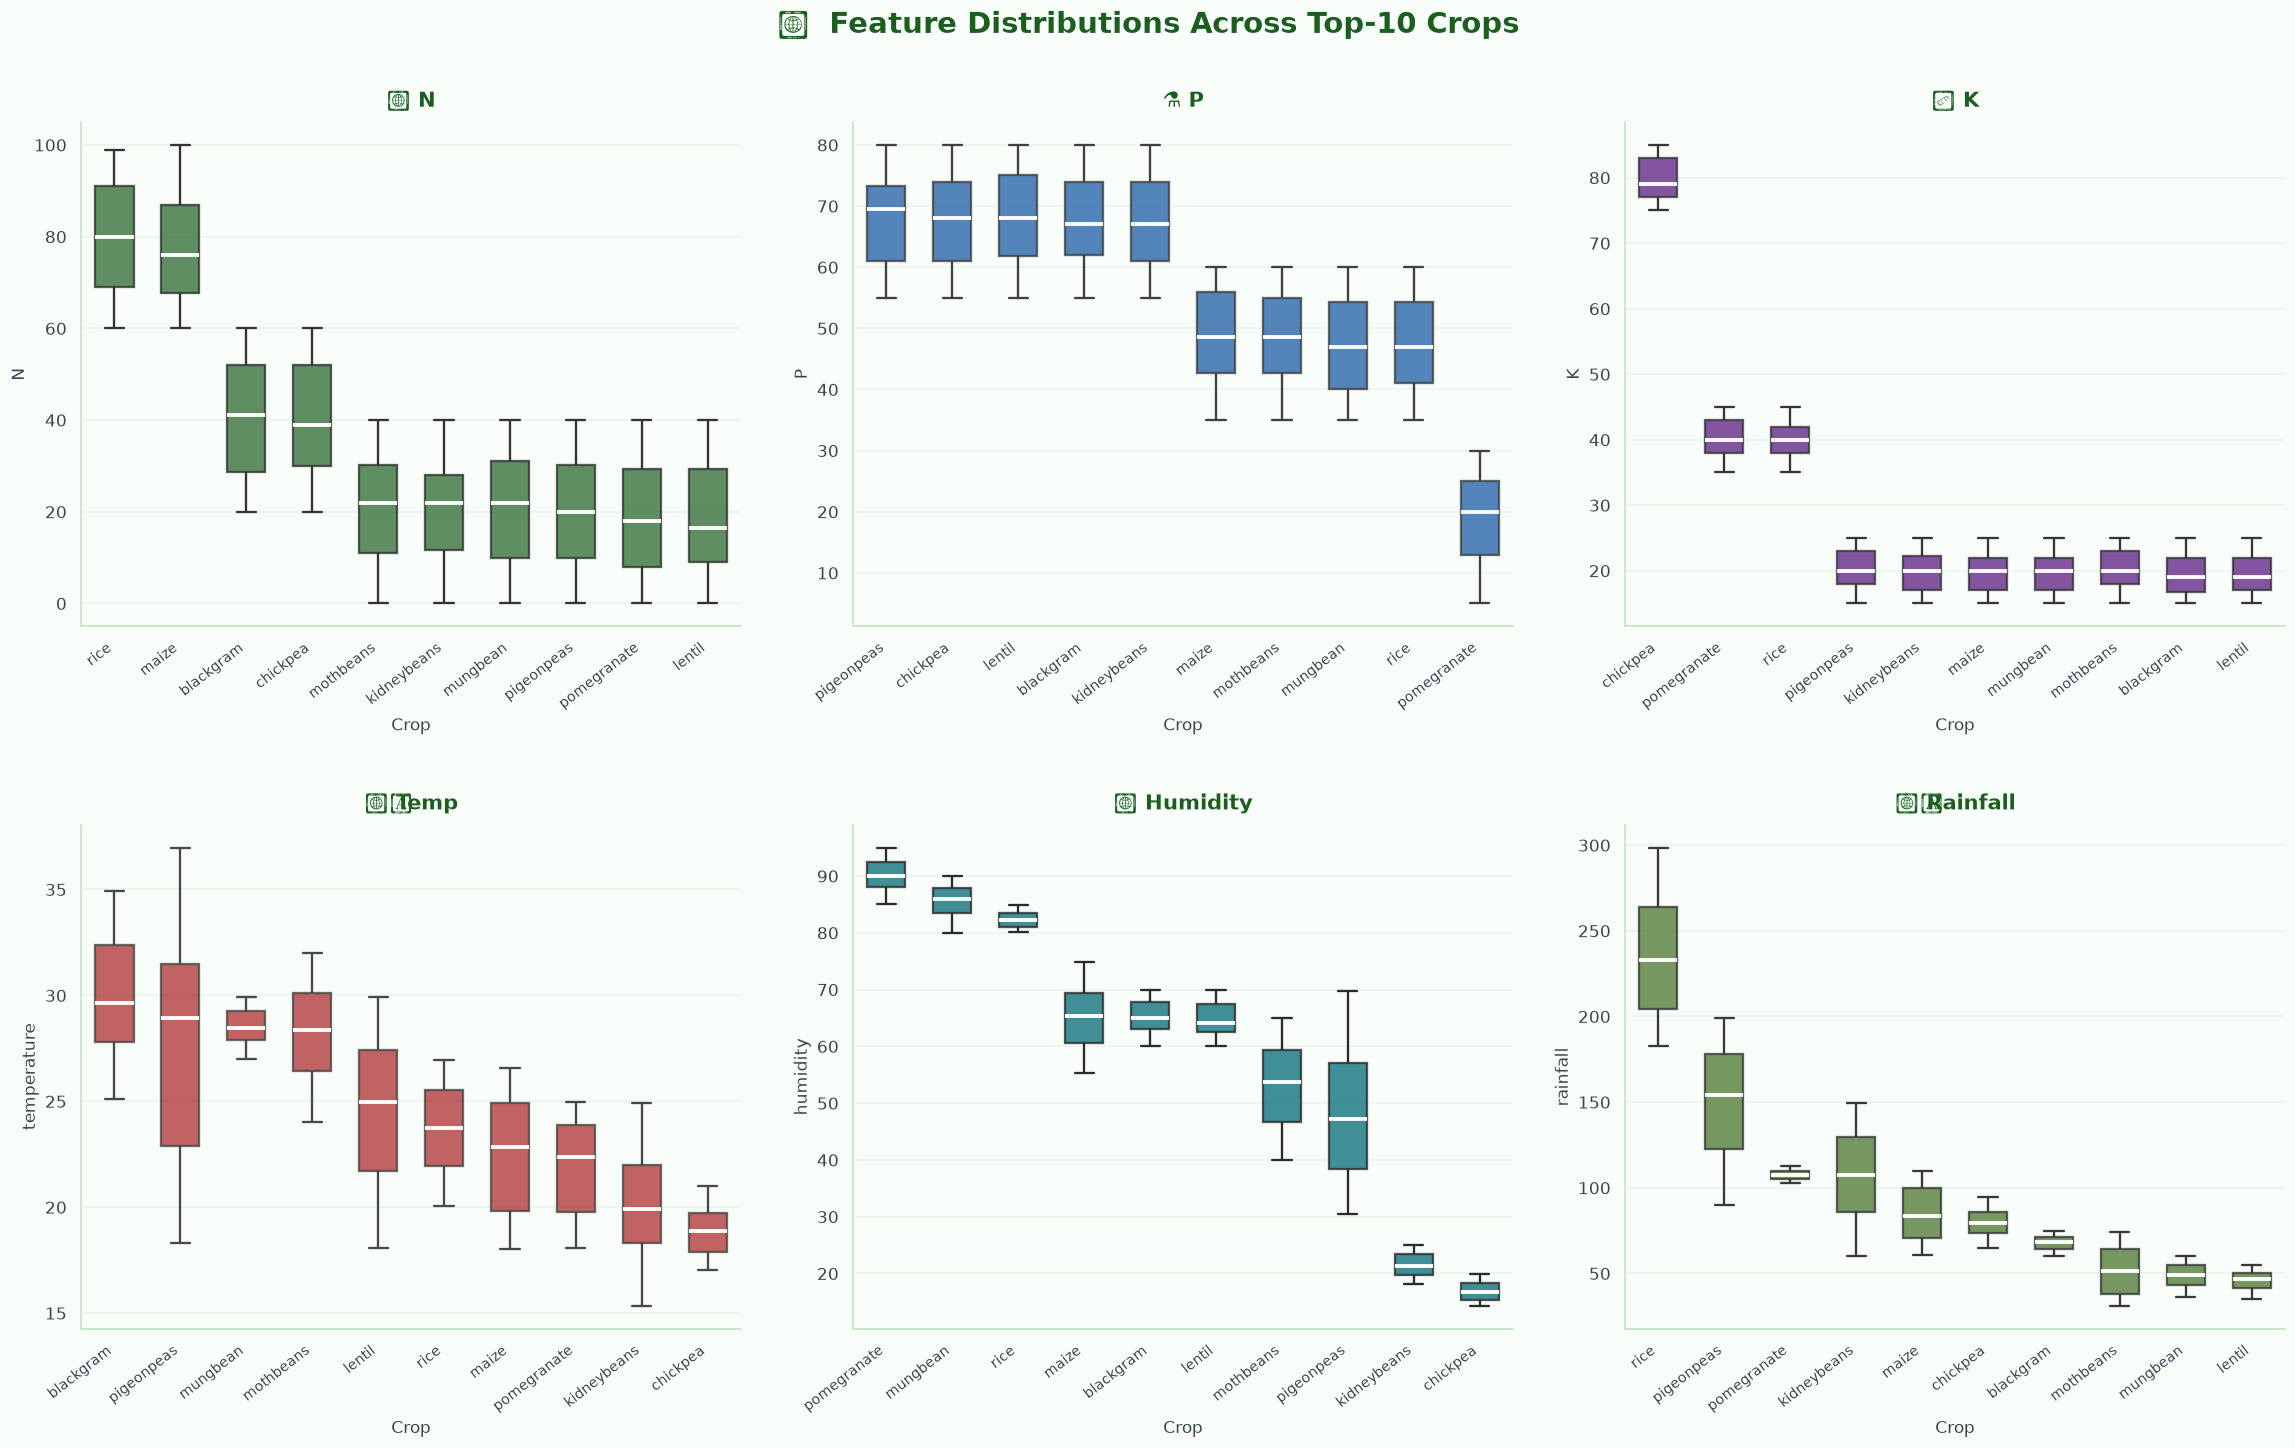

In [12]:
# ─── 3.4  Average N · P · K per Crop ────────────────────────────────────────
avg_npk        = df.groupby('label')[['N', 'P', 'K']].mean().reset_index()
avg_npk_melted = avg_npk.melt(id_vars='label', var_name='Nutrient', value_name='Average Value')

npk_palette = {'N': '#43a047', 'P': '#1e88e5', 'K': '#8e24aa'}

fig, ax = plt.subplots(figsize=(19, 7), facecolor=BG)
ax.set_facecolor(BG)

sns.barplot(
    data=avg_npk_melted, x='label', y='Average Value',
    hue='Nutrient', palette=npk_palette, ax=ax,
    edgecolor='white', linewidth=0.9, alpha=0.88,
)

ax.set_title("🌿  Average N · P · K Nutrient Levels per Crop",
             fontsize=18, fontweight='bold', color=GREEN, pad=16)
ax.set_xlabel('Crop Type', fontsize=13, labelpad=10)
ax.set_ylabel('Average Nutrient Ratio', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=10)
ax.legend(title='Nutrient', title_fontsize=12, fontsize=11,
          loc='upper right', framealpha=0.92, edgecolor='#c8e6c9')
ax.grid(axis='y', color='#e8f5e9', linewidth=1)
plt.tight_layout()
plt.show()

# ─── 3.5  Feature Distributions Across Top-10 Crops (Boxplots) ──────────────
top_crops = df['label'].value_counts().head(10).index.tolist()
df_top    = df[df['label'].isin(top_crops)]

box_features = ['N', 'P', 'K', 'temperature', 'humidity', 'rainfall']
box_colors   = ['#2e7d32', '#1565c0', '#6a1b9a', '#c62828', '#00838f', '#558b2f']
box_icons    = ['🌿 N', '⚗️ P', '🪨 K', '🌡️ Temp', '💧 Humidity', '🌧️ Rainfall']

fig, axes = plt.subplots(2, 3, figsize=(21, 13), facecolor=BG)
axes = axes.flatten()

for i, (col, color, label) in enumerate(zip(box_features, box_colors, box_icons)):
    ax = axes[i]
    ax.set_facecolor(BG)

    order = (df_top.groupby('label')[col]
             .median()
             .sort_values(ascending=False)
             .index.tolist())

    sns.boxplot(
        data=df_top, x='label', y=col, order=order,
        color=color, width=0.58, linewidth=1.5, ax=ax,
        flierprops=dict(marker='o', markersize=3.5, alpha=0.45,
                        markerfacecolor=color, markeredgecolor='none'),
        medianprops=dict(color='white', linewidth=2.5),
        boxprops=dict(alpha=0.80),
    )

    ax.set_title(label, fontsize=14, fontweight='bold', color=GREEN, pad=10)
    ax.set_xlabel('Crop', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=38, ha='right', fontsize=9)
    ax.grid(axis='y', color='#e8f5e9', linewidth=1)

fig.suptitle("📦  Feature Distributions Across Top-10 Crops",
             fontsize=19, fontweight='bold', color=GREEN, y=1.01)
plt.tight_layout(h_pad=3.5, w_pad=2.5)

plt.savefig(
    "../results/feature_distributions_top_10_crops.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()